# Implementacion Del ejercicio

## Importacion de librerias

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, normaltest, kstest
from tabulate import tabulate

## Funciones usadas

In [24]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [25]:
def analizar_categoricas(df):
    resultados = []

    # Detectar variables categóricas (object, category o booleanas)
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)
        proporcion = df[col].value_counts(normalize=True, dropna=False)
        nulos = df[col].isna().sum()

        # Tomamos la categoría más frecuente
        categoria_moda = conteo.index[0] if not conteo.empty else None
        frecuencia_moda = conteo.iloc[0] if not conteo.empty else None
        porcentaje_moda = proporcion.iloc[0] if not conteo.empty else None

        resultados.append({
            "variable": col,
            "cantidad_categorias": df[col].nunique(dropna=False),
            "categoria_mas_frecuente": categoria_moda,
            "frecuencia_mas_frecuente": frecuencia_moda,
            "porcentaje_mas_frecuente": porcentaje_moda,
            "nulos": nulos,
            "porcentaje_nulos": nulos / len(df)
        })
    
    return pd.DataFrame(resultados).sort_values(by="cantidad_categorias", ascending=False)

In [26]:
def Graficar_Categoricas(df, tipo="barra"):
    # Detectar variables categóricas
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns
    resultados = {}

    if len(categoricas) == 0:
        print("No se detectaron variables categóricas en el DataFrame.")
        return

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)  # incluir NaN si hay
        resultados[col] = conteo

        if tipo == "barra":
            plt.figure(figsize=(6,4))
            conteo.plot(kind="bar", color="skyblue", edgecolor="black")
            plt.title(f"Frecuencia de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif tipo == "pastel":
            plt.figure(figsize=(6,6))
            conteo.plot(kind="pie", autopct='%1.1f%%', 
                        colors=plt.cm.Set3.colors, startangle=90)
            plt.title(f"Distribución de {col}")
            plt.ylabel("")
            plt.tight_layout()
            plt.show()
        else:
            raise ValueError("El parámetro 'tipo' debe ser 'barra' o 'pastel'.")

    return resultados

In [27]:
def resumen_numericas(df):

    # Seleccionar columnas numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
    
    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None
    
    # Usamos describe() y agregamos info adicional
    resumen = df[numericas].describe().T  # Transpuesto para mayor claridad
    resumen["varianza"] = df[numericas].var()
    resumen["mediana"] = df[numericas].median()
    
    return resumen

In [28]:
def graficar_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return

    for col in numericas:
        plt.figure(figsize=(12,4))

        # Histograma
        plt.subplot(1,2,1)
        df[col].hist(bins=20, color="skyblue", edgecolor="black")
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

        # Boxplot
        plt.subplot(1,2,2)
        plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor="lightgreen", color="black"),
                    medianprops=dict(color="red"))
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)

        plt.tight_layout()
        plt.show()

In [29]:
def prueba_normalidad(df, alpha=0.05):
    resultados = []

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=[np.number]).columns

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) < 8:  # muy pocas muestras → no confiable
            resultados.append({
                "variable": col,
                "n_muestras": len(serie),
                "shapiro_p": np.nan,
                "dagostino_p": np.nan,
                "ks_p": np.nan,
                "es_normal (alpha=0.05)": "Muestra insuficiente"
            })
            continue

        # Shapiro-Wilk (solo si n <= 5000, más grande no recomendado)
        stat_shapiro, p_shapiro = shapiro(serie) if len(serie) <= 5000 else (np.nan, np.nan)

        # D’Agostino y Pearson
        stat_dagostino, p_dagostino = normaltest(serie)

        # Kolmogorov-Smirnov contra normal estándar
        stat_ks, p_ks = kstest(
            (serie - serie.mean()) / serie.std(ddof=0), 'norm'
        )

        # Veredicto final
        es_normal = (
            (np.isnan(p_shapiro) or p_shapiro > alpha) and
            (p_dagostino > alpha) and
            (p_ks > alpha)
        )

        resultados.append({
            "variable": col,
            "n_muestras": len(serie),
            "shapiro_p": p_shapiro,
            "dagostino_p": p_dagostino,
            "ks_p": p_ks,
            "es_normal (alpha=0.05)": es_normal
        })

    return pd.DataFrame(resultados).sort_values(by="es_normal (alpha=0.05)", ascending=False)

In [30]:
def mapa_calor_nulos(df, figsize=(10,6), cmap="viridis"):
    plt.figure(figsize=figsize)
    sns.heatmap(df.isnull(), 
                cbar=False, 
                cmap=cmap, 
                yticklabels=False)
    plt.title("Mapa de calor de valores faltantes", fontsize=14)
    plt.show()

In [31]:
def contar_na_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None

    # Contar NAs en cada variable numérica
    na_counts = df[numericas].isna().sum()

    return na_counts

In [32]:
def analizar_gaps(df, fecha_col, freq="D", periodo_estacional=None, mostrar_tabla=True):
    """
    Analiza los datos faltantes en un dataframe de series de tiempo y muestra resumen tabular.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    fecha_col : str
        Nombre de la columna con las fechas.
    freq : str
        Frecuencia esperada de la serie ("D"=diaria, "H"=horaria, etc.).
    periodo_estacional : int, opcional
        Periodo estacional conocido (ej: 7 para diaria con estacionalidad semanal,
        24 para horaria con ciclo diario).
    mostrar_tabla : bool
        Si True, muestra resumen tabular en consola.
    """

    # Asegurar índice temporal
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col])
    df = df.set_index(fecha_col).asfreq(freq)

    resultados = {}

    for col in df.columns:
        if df[col].isna().sum() == 0:
            continue

        # Identificar posiciones faltantes
        na_mask = df[col].isna().astype(int)

        # Encontrar huecos consecutivos (gaps)
        df[col + "_gap_id"] = (na_mask.diff().fillna(0) == 1).cumsum() * na_mask

        gaps = df.groupby(col + "_gap_id").size()
        gaps = gaps[gaps.index != 0]  # quitar "no-gap"

        resumen = pd.DataFrame({
            "Variable": col,
            "Inicio": [df.index[df[col + "_gap_id"] == g][0] for g in gaps.index],
            "Fin": [df.index[df[col + "_gap_id"] == g][-1] for g in gaps.index],
            "Duración": gaps.values
        })

        # Clasificación según estacionalidad (si se pasa)
        if periodo_estacional:
            resumen["Ratio estacional"] = resumen["Duración"] / periodo_estacional
            resumen["Clasificación"] = pd.cut(
                resumen["Ratio estacional"],
                bins=[0, 0.25, 0.75, 1.5, np.inf],
                labels=["Pequeño", "Moderado", "Significativo", "Largo"]
            )
        else:
            resumen["Clasificación"] = "Sin periodo definido"

        resultados[col] = resumen

        if mostrar_tabla:
            print(f"\n📌 Gaps en variable: {col}")
            print(tabulate(resumen, headers="keys", tablefmt="pretty", showindex=False))

    return resultados

## Cargado y revision inicial de los datos

In [33]:
df = pd.read_csv("Base_imputacion_mixta_1000.csv")

In [34]:
Summary(df,"Datos")

Hoja: Datos

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,1000,12,1850,0



Encabezado:


,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
0,2024-01-01,F,Medellín,NaN,B,Unión libre,19.0,161.821754,3574.753806,1832.731832,640.465372,119.202995
1,2024-01-02,F,Barranquilla,NaN,B,NaN,52.0,167.819566,3163.626815,NaN,533.108430,124.457874
2,2024-01-03,M,Bogotá,Secundaria,B,Soltero/a,38.0,165.756219,2765.672259,1219.535074,491.016910,NaN
3,2024-01-04,F,Bogotá,NaN,B,Casado/a,57.0,160.642670,4320.397345,1908.324816,NaN,129.426792
4,2024-01-05,M,Cali,Técnico,B,Soltero/a,67.0,151.402909,NaN,1887.385697,610.213994,133.916319


Observamos prescencia de datos faltantes, en total 1850, ademas de 1000 filas y 12 columnas con 0 filas duplicadas, a continuacion revisaremos la adecuada lectura de los tipos de datos

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               1000 non-null   object 
 1   sexo                980 non-null    object 
 2   ciudad              950 non-null    object 
 3   nivel_educativo     900 non-null    object 
 4   segmento            800 non-null    object 
 5   estado_civil        650 non-null    object 
 6   edad                970 non-null    float64
 7   altura_cm           920 non-null    float64
 8   ingresos            880 non-null    float64
 9   gasto_mensual       750 non-null    float64
 10  puntuacion_credito  500 non-null    float64
 11  demanda             850 non-null    float64
dtypes: float64(6), object(6)
memory usage: 93.9+ KB


Observamos que todos los datos están adecuadamente detectados excepto por fecha que está siendo detectada como un object

In [36]:
df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d")

## Analisis exploratorio de datos

In [37]:
analizar_categoricas(df)

,variable,cantidad_categorias,categoria_mas_frecuente,frecuencia_mas_frecuente,porcentaje_mas_frecuente,nulos,porcentaje_nulos
1,ciudad,6,Bogotá,307,0.307,50,0.05
4,estado_civil,5,NaN,350,0.350,350,0.35
2,nivel_educativo,5,Secundaria,317,0.317,100,0.10
3,segmento,4,B,457,0.457,200,0.20
0,sexo,3,F,518,0.518,20,0.02


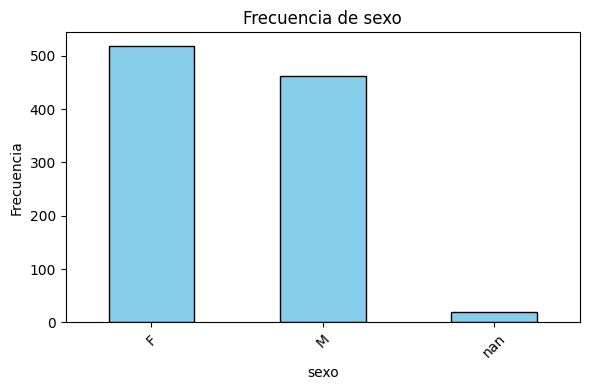

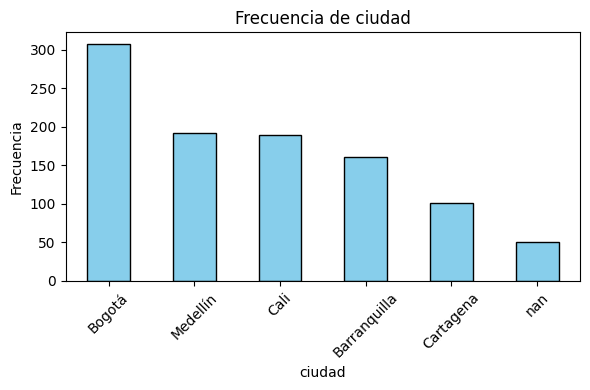

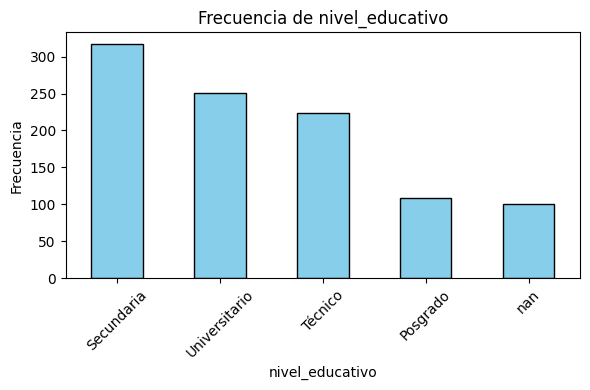

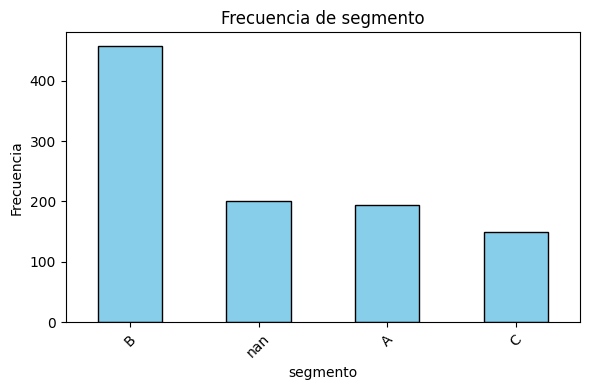

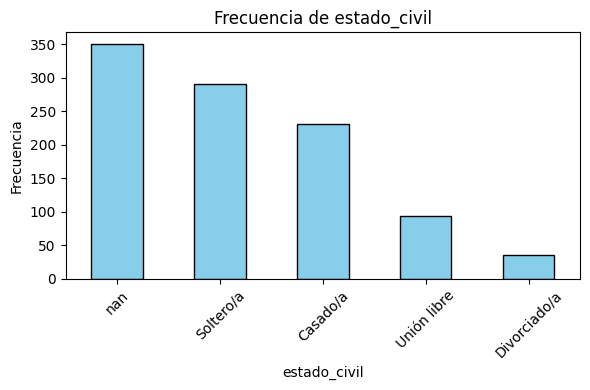

{'sexo': sexo
 F      518
 M      462
 NaN     20
 Name: count, dtype: int64,
 'ciudad': ciudad
 Bogotá          307
 Medellín        192
 Cali            189
 Barranquilla    161
 Cartagena       101
 NaN              50
 Name: count, dtype: int64,
 'nivel_educativo': nivel_educativo
 Secundaria       317
 Universitario    251
 Técnico          224
 Posgrado         108
 NaN              100
 Name: count, dtype: int64,
 'segmento': segmento
 B      457
 NaN    200
 A      194
 C      149
 Name: count, dtype: int64,
 'estado_civil': estado_civil
 NaN             350
 Soltero/a       290
 Casado/a        231
 Unión libre      93
 Divorciado/a     36
 Name: count, dtype: int64}

In [38]:
Graficar_Categoricas(df)

In [39]:
resumen_numericas(df)

,count,mean,std,min,25%,50%,75%,max,varianza,mediana
edad,970.0,42.861856,14.621382,18.000000,30.000000,43.000000,55.000000,69.000000,2.137848e+02,43.000000
altura_cm,920.0,167.760096,9.275530,140.000000,161.488768,167.714614,173.999069,195.766921,8.603545e+01,167.714614
ingresos,880.0,3681.294745,1079.326096,487.662547,2999.416229,3669.620507,4375.093656,7016.246936,1.164945e+06,3669.620507
gasto_mensual,750.0,1687.810749,582.070174,100.000000,1309.239768,1676.193764,2063.260990,3532.593603,3.388057e+05,1676.193764
puntuacion_credito,500.0,599.077500,79.828186,373.657944,544.467843,599.692595,653.345068,823.539585,6.372539e+03,599.692595
demanda,850.0,160.305759,25.357794,99.875828,139.505538,160.721251,181.100754,222.093047,6.430177e+02,160.721251


In [40]:
contar_na_numericas(df) / len(df)

edad                  0.03
altura_cm             0.08
ingresos              0.12
gasto_mensual         0.25
puntuacion_credito    0.50
demanda               0.15
dtype: float64

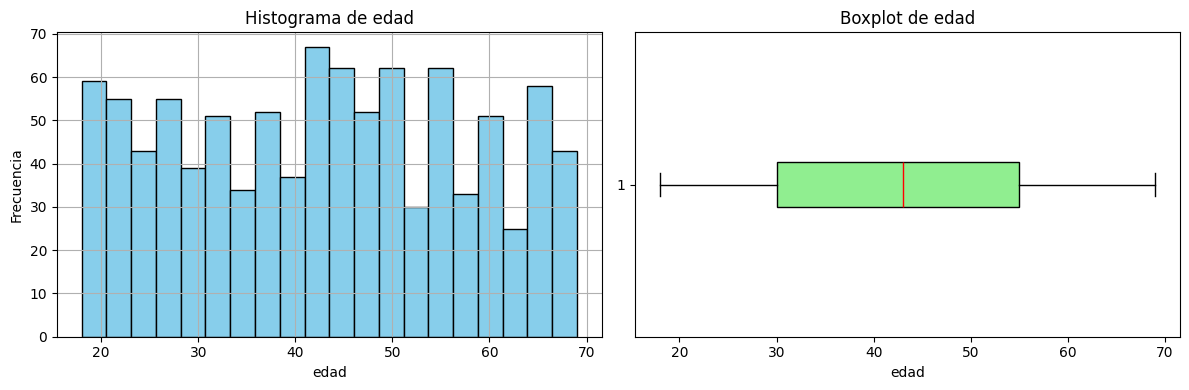

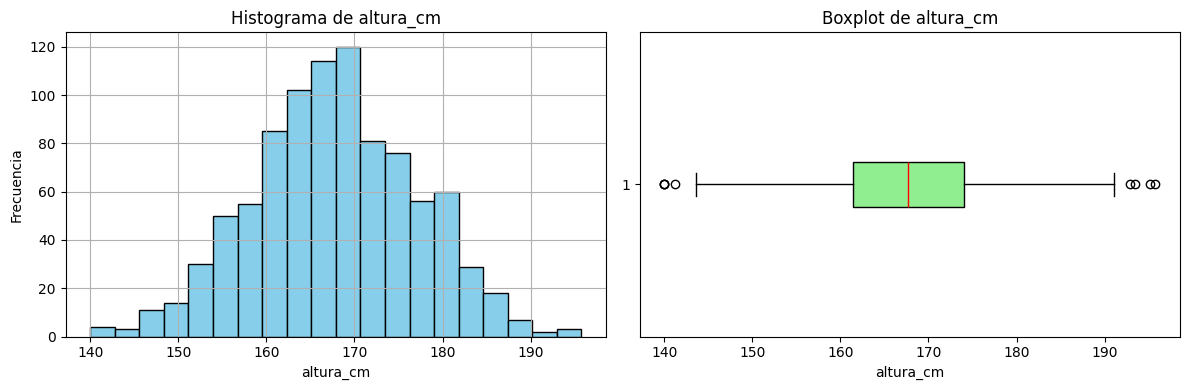

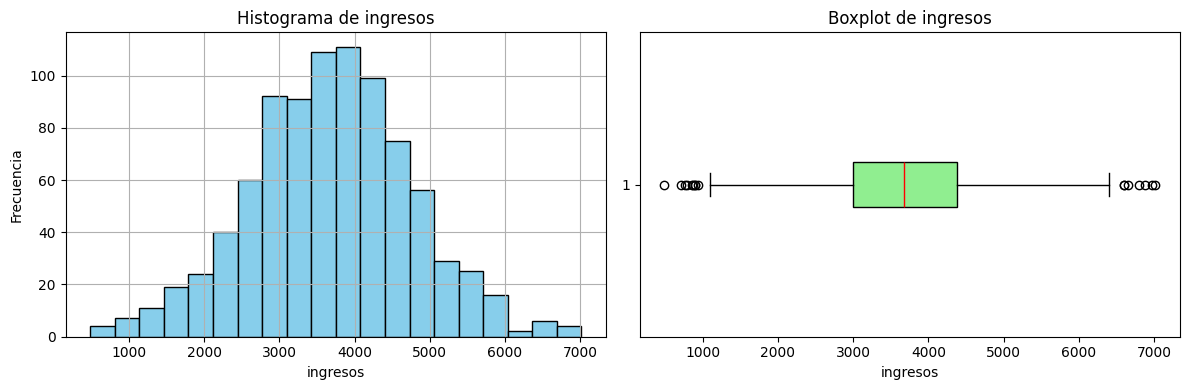

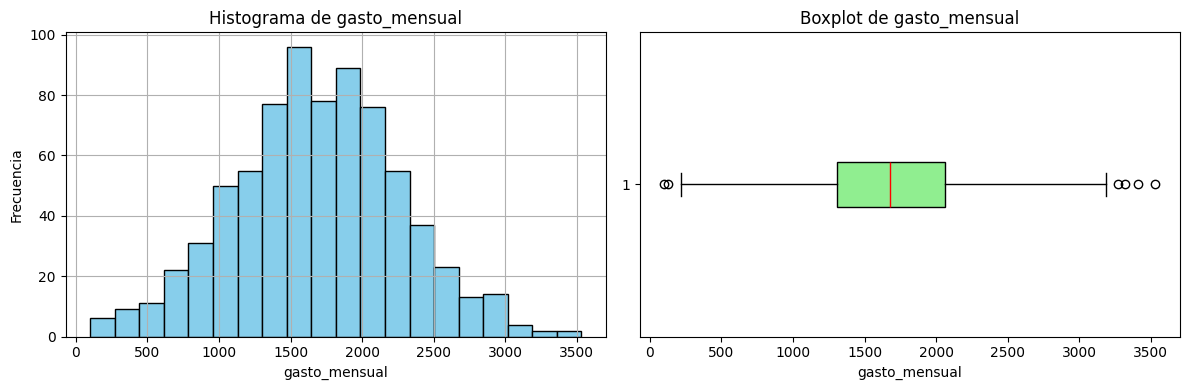

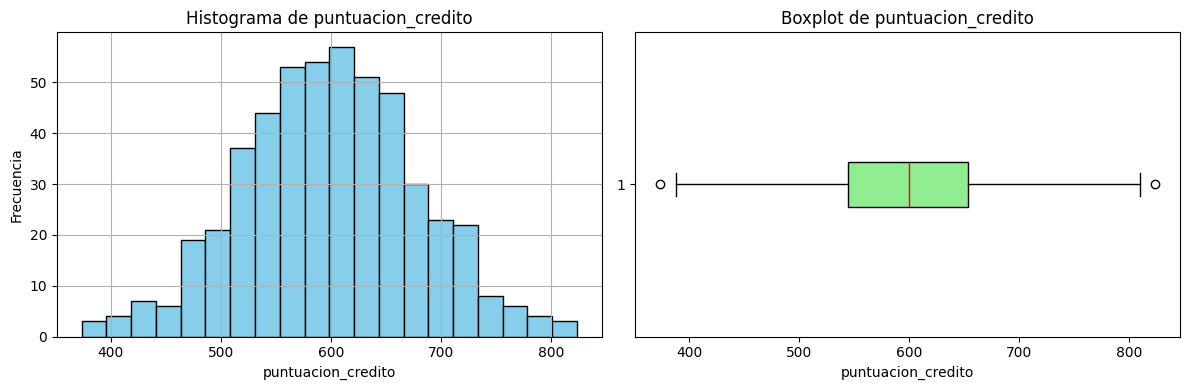

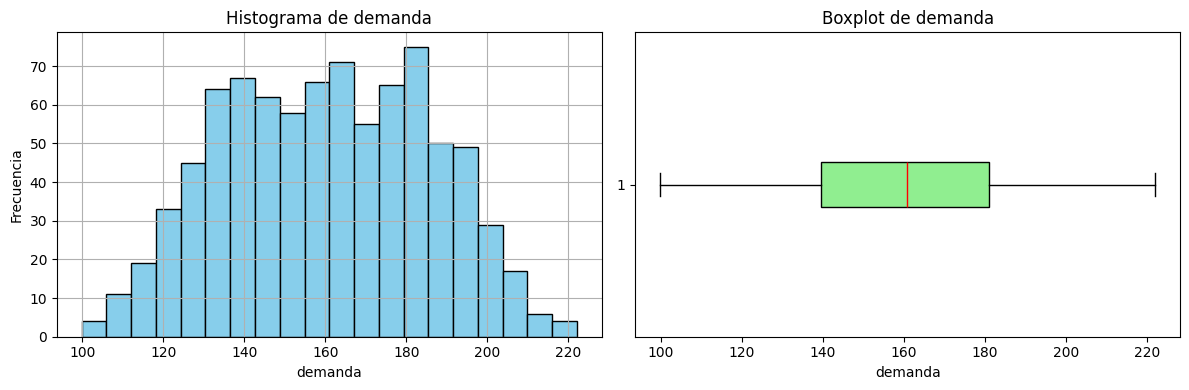

In [41]:
graficar_numericas(df)

mapa de calor de los valores faltantes

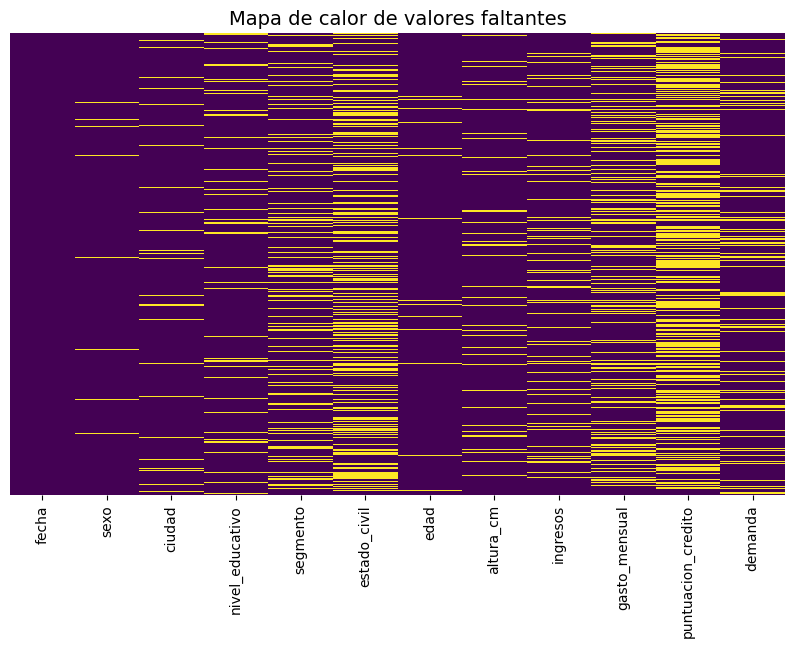

In [42]:
mapa_calor_nulos(df)

In [43]:
prueba_normalidad(df)

,variable,n_muestras,shapiro_p,dagostino_p,ks_p,es_normal (alpha=0.05)
1,altura_cm,920,5.911472e-01,7.946680e-01,0.725425,True
2,ingresos,880,3.244752e-01,6.173557e-01,0.899760,True
3,gasto_mensual,750,6.752081e-01,8.791065e-01,0.961382,True
4,puntuacion_credito,500,9.405074e-01,9.651871e-01,0.997282,True
0,edad,970,1.132185e-15,9.628678e-93,0.000063,False
5,demanda,850,1.129628e-07,1.958694e-19,0.025404,False


## Clasificacion de datos faltantes segun lo observado

In [44]:
analizar_gaps(df,fecha_col= "fecha", freq="D", periodo_estacional= 7)


📌 Gaps en variable: sexo
+----------+---------------------+---------------------+----------+---------------------+---------------+
| Variable |       Inicio        |         Fin         | Duración |  Ratio estacional   | Clasificación |
+----------+---------------------+---------------------+----------+---------------------+---------------+
|   sexo   | 2024-01-09 00:00:00 | 2024-01-09 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
|   sexo   | 2024-01-14 00:00:00 | 2024-01-14 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
|   sexo   | 2024-05-07 00:00:00 | 2024-05-07 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
|   sexo   | 2024-05-30 00:00:00 | 2024-05-30 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
|   sexo   | 2024-07-06 00:00:00 | 2024-07-06 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
|   sexo   | 2024-07-21 00:00:00 | 2024-07-21 00:00:00 |    1     | 0.14285714285714285 |    Pequeño    |
|   sexo   | 2024-09

{'sexo':    Variable     Inicio        Fin  Duración  Ratio estacional Clasificación
 0      sexo 2024-01-09 2024-01-09         1          0.142857       Pequeño
 1      sexo 2024-01-14 2024-01-14         1          0.142857       Pequeño
 2      sexo 2024-05-07 2024-05-07         1          0.142857       Pequeño
 3      sexo 2024-05-30 2024-05-30         1          0.142857       Pequeño
 4      sexo 2024-07-06 2024-07-06         1          0.142857       Pequeño
 5      sexo 2024-07-21 2024-07-21         1          0.142857       Pequeño
 6      sexo 2024-09-16 2024-09-16         1          0.142857       Pequeño
 7      sexo 2024-09-22 2024-09-22         1          0.142857       Pequeño
 8      sexo 2025-03-13 2025-03-13         1          0.142857       Pequeño
 9      sexo 2025-03-15 2025-03-15         1          0.142857       Pequeño
 10     sexo 2025-03-19 2025-03-19         1          0.142857       Pequeño
 11     sexo 2025-05-01 2025-05-01         1          0.142857      

## Discusion sobre imputabilidad

## Representacion de la imputacion

## Evaluacion de la imputacion

## Conclusion preliminar